In [30]:
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
import pandas as pd 
import numpy as np
%matplotlib inline

In [31]:
x,y = make_blobs(n_samples=1000,centers=3,n_features=2,)

In [32]:
# We Willnot use y value because it is a unsupervised ml algorithm

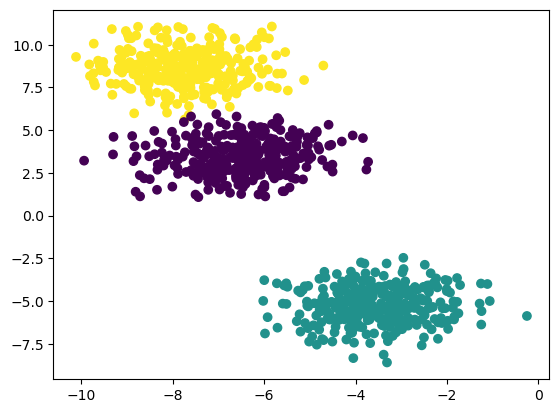

In [33]:
plt.scatter(x[:,0],x[:,1],c=y)
plt.show()

In [34]:
## Standardization -- Feature Scaling Technique
from sklearn.preprocessing import StandardScaler

In [35]:
scaler = StandardScaler()

In [36]:
from sklearn.model_selection import train_test_split
xtrain,xtest1,ytrain,ytest = train_test_split(x,y,test_size=0.33,random_state=42)

In [37]:
xscaled = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest1)

In [38]:
from sklearn.cluster import KMeans

In [39]:
## Elbow Method to Select K Value
wcss=[]
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(xscaled)
    wcss.append(kmeans.inertia_)
wcss

[1340.0000000000007,
 302.5903338042124,
 172.66881081056414,
 139.04870453894418,
 112.14438567457451,
 79.23909534451514,
 69.98453945342263,
 60.75216488994448,
 55.146296347717694,
 46.50558874013124]

In [40]:
# import warnings
# warnings.filterwarnings("ignore")


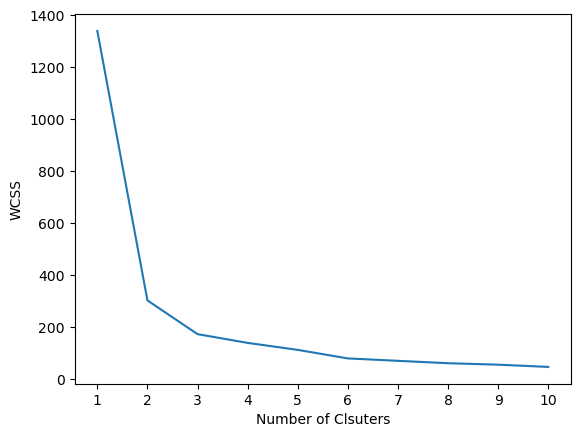

In [41]:
## Plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clsuters")
plt.ylabel("WCSS")
plt.show()

In [42]:
kmeans = KMeans(n_clusters=3,init="k-means++")
kmeans.fit_predict(xscaled)

array([0, 2, 1, 1, 1, 2, 2, 1, 1, 0, 1, 2, 1, 1, 2, 1, 1, 2, 1, 0, 1, 1,
       0, 0, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 0, 2, 0, 0, 2, 1, 2, 0, 0,
       2, 0, 2, 1, 2, 0, 1, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 1, 1, 2, 1, 0,
       1, 2, 1, 2, 2, 1, 0, 2, 2, 2, 2, 0, 1, 1, 2, 0, 2, 0, 1, 2, 1, 1,
       2, 0, 1, 0, 0, 2, 0, 0, 0, 2, 2, 1, 1, 0, 1, 1, 2, 2, 0, 0, 1, 0,
       1, 0, 2, 2, 2, 0, 2, 1, 0, 1, 1, 0, 2, 0, 1, 2, 2, 2, 0, 1, 0, 1,
       1, 2, 2, 0, 1, 0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 2, 0, 2, 0, 2, 1, 1,
       2, 2, 2, 0, 1, 1, 1, 1, 0, 0, 2, 0, 0, 2, 2, 0, 2, 0, 0, 2, 1, 0,
       2, 2, 2, 0, 0, 2, 0, 2, 0, 1, 1, 0, 1, 2, 1, 1, 0, 2, 0, 0, 2, 0,
       0, 2, 0, 2, 2, 2, 1, 0, 1, 1, 0, 0, 2, 1, 2, 2, 1, 1, 1, 1, 0, 2,
       0, 1, 0, 1, 0, 2, 0, 0, 1, 2, 1, 0, 1, 0, 1, 1, 2, 0, 0, 1, 1, 1,
       0, 0, 2, 2, 1, 0, 0, 1, 1, 0, 0, 2, 1, 1, 0, 2, 0, 1, 1, 1, 2, 2,
       0, 0, 0, 2, 0, 2, 1, 1, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2, 0, 0, 1, 0,
       0, 2, 1, 0, 2, 1, 2, 1, 0, 2, 0, 2, 2, 2, 2,

In [43]:
ypred = kmeans.predict(xtest)

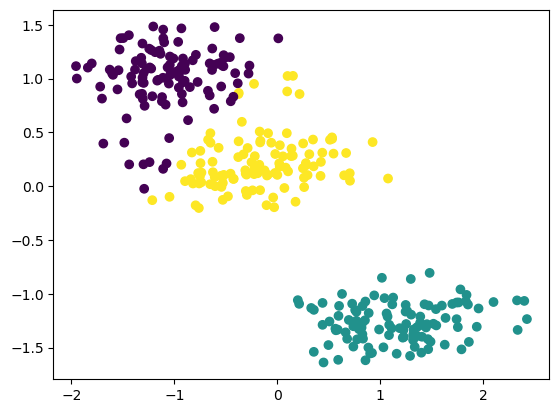

In [46]:
plt.scatter(xtest[:,0],xtest[:,1],c=ypred)
plt.show()

In [ ]:
## Validating k  Value if we didnt found any proper elbow abruption

In [ ]:
## Kneelocator
## Silhoutte scoring

In [48]:
## Kneelocator
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable


In [49]:
from kneed import KneeLocator

In [50]:
k1 = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
k1.elbow


np.int64(2)

In [ ]:
## Silhoutte Scoring 

In [51]:
from sklearn.metrics import silhouette_score

In [55]:
silhoutte_coefficients =[]
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(xscaled)
    score = silhouette_score(xscaled,kmeans.labels_)
    silhoutte_coefficients.append(score)
for i in silhoutte_coefficients:
    print(i)

0.6802178439206413
0.5528295282658752
0.5183727739160073
0.48218570076345707
0.43994747633325254
0.4287061745017817
0.42333088236410027
0.3999433741859763
0.3877038046079161


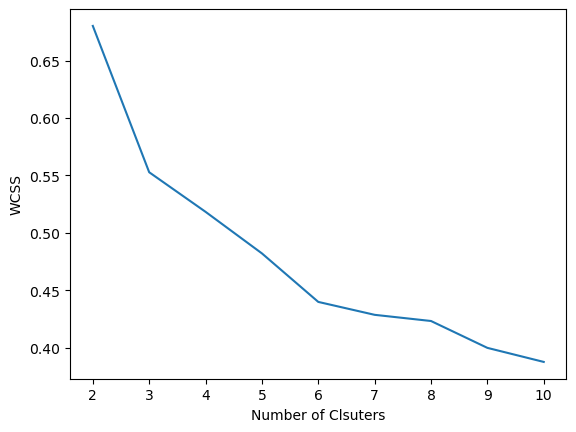

In [ ]:
## Plot elbow curve
plt.plot(range(2,11),silhoutte_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhoutte scoring")
plt.show()

In [ ]:
# Take high value silhoutte scoring  having k.
